# Week 7 - RAG System on ML/AI ArXiv Papers

Built a retrieval-augmented QA system over a sample of ML/AI arXiv papers, combining keyword and embedding-based search with re-ranking before generating answers. The goal was to see how much retrieval quality actually affects the final answer compared to just asking the model directly.

## 1. Setup

In [26]:
!pip install -q sentence-transformers faiss-cpu transformers datasets accelerate rank_bm25

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import faiss

from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

sns.set_style("whitegrid")
%matplotlib inline

In [28]:
print("GPU available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
device = "cuda" if torch.cuda.is_available() else "cpu"
device

GPU available: True
GPU count: 2


'cuda'

## 2. Dataset

Using **ML-ArXiv-Papers** from Hugging Face - title + abstract for ML/AI papers pulled from arXiv's cs.LG category. Taking a random sample of 4,000 papers to keep things fast while still giving broad topic coverage.

In [29]:
raw = load_dataset("CShorten/ML-ArXiv-Papers")["train"]
papers_df = raw.to_pandas()[["title", "abstract"]].dropna().sample(4000, random_state=42).reset_index(drop=True)
papers_df["paper_id"] = papers_df.index
print(papers_df.shape)
papers_df.head()

(4000, 3)


,title,abstract,paper_id
0,SVD Perspectives for Augmenting DeepONet Flexi...,Deep operator networks (DeepONets) are power...,0
1,Towards robust audio spoofing detection: a det...,"Automatic speaker verification, like every o...",1
2,Guided Random Forest in the RRF Package,Random Forest (RF) is a powerful supervised ...,2
3,Best Arm Identification in Generalized Linear ...,"Motivated by drug design, we consider the be...",3
4,Conditional Affordance Learning for Driving in...,Most existing approaches to autonomous drivi...,4


## 3. Exploratory Data Analysis

In [30]:
papers_df["abstract_words"] = papers_df["abstract"].apply(lambda x: len(x.split()))
papers_df["title_words"] = papers_df["title"].apply(lambda x: len(x.split()))
papers_df[["abstract_words", "title_words"]].describe()

,abstract_words,title_words
count,4000.000000,4000.000000
mean,166.634500,8.984250
std,50.098327,3.166703
min,8.000000,1.000000
25%,131.000000,7.000000
50%,164.000000,9.000000
75%,199.250000,11.000000
max,364.000000,24.000000


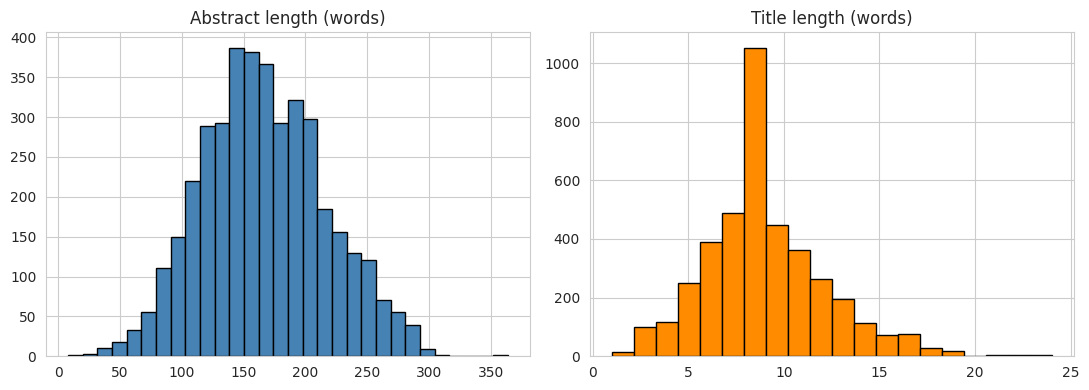

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(papers_df["abstract_words"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Abstract length (words)")
axes[1].hist(papers_df["title_words"], bins=20, color="darkorange", edgecolor="black")
axes[1].set_title("Title length (words)")
plt.tight_layout()
plt.show()

Abstracts mostly fall in the typical 100-250 word range expected for arXiv papers, with a long tail of longer ones. Titles are short and dense with technical terms, which is exactly what should help the keyword-based side of hybrid retrieval later on.

## 4. Building the Corpus for Retrieval

Each paper is treated as a single chunk (title + abstract combined). Abstracts are short enough that splitting them further would just fragment the context unnecessarily.

In [32]:
papers_df["text"] = papers_df["title"] + ". " + papers_df["abstract"]
chunks_df = papers_df[["paper_id", "title", "text"]].copy()
chunks_df.head()

,paper_id,title,text
0,0,SVD Perspectives for Augmenting DeepONet Flexi...,SVD Perspectives for Augmenting DeepONet Flexi...
1,1,Towards robust audio spoofing detection: a det...,Towards robust audio spoofing detection: a det...
2,2,Guided Random Forest in the RRF Package,Guided Random Forest in the RRF Package. Ran...
3,3,Best Arm Identification in Generalized Linear ...,Best Arm Identification in Generalized Linear ...
4,4,Conditional Affordance Learning for Driving in...,Conditional Affordance Learning for Driving in...


## 5. Embeddings

Using `all-MiniLM-L6-v2`.

In [33]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

texts = chunks_df["text"].tolist()

if torch.cuda.device_count() >= 2:
    pool = embed_model.start_multi_process_pool(target_devices=["cuda:0", "cuda:1"])
    chunk_embeddings = embed_model.encode_multi_process(texts, pool, batch_size=64)
    embed_model.stop_multi_process_pool(pool)
else:
    chunk_embeddings = embed_model.encode(texts, batch_size=64, show_progress_bar=True, device=device)

embed_model = embed_model.to(device)
chunk_embeddings = np.array(chunk_embeddings)
chunk_embeddings.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_58/1821498771.py:7: DeprecationWarning: The `encode_multi_process` method has been deprecated, and its functionality has been integrated into `encode`. You can now call `encode` with the same parameters to achieve multi-process encoding.
  chunk_embeddings = embed_model.encode_multi_process(texts, pool, batch_size=64)


(4000, 384)

## 6. Dense Index (FAISS) + Keyword Index (BM25)

In [34]:
faiss.normalize_L2(chunk_embeddings)
dim = chunk_embeddings.shape[1]
dense_index = faiss.IndexFlatIP(dim)
dense_index.add(chunk_embeddings)
dense_index.ntotal

4000

In [35]:
tokenized_corpus = [t.lower().split() for t in chunks_df["text"]]
bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index ready over", len(tokenized_corpus), "docs")

BM25 index ready over 4000 docs


## 7. Hybrid Retrieval

Dense search and BM25 search are run independently, their scores are min-max normalized, and combined with equal weight. This catches cases pure vector search misses when a query uses exact technical terms (model names, method names) that matter more as keywords than as semantics.

In [36]:
def hybrid_retrieve(query, top_n=20):
    q_emb = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    dense_scores, dense_idx = dense_index.search(q_emb, top_n)
    dense_scores, dense_idx = dense_scores[0], dense_idx[0]

    bm25_scores_all = bm25.get_scores(query.lower().split())
    bm25_top_idx = np.argsort(bm25_scores_all)[::-1][:top_n]

    candidate_idx = list(set(dense_idx.tolist()) | set(bm25_top_idx.tolist()))

    dense_score_map = {i: s for i, s in zip(dense_idx, dense_scores)}
    d_vals = np.array([dense_score_map.get(i, 0.0) for i in candidate_idx])
    b_vals = np.array([bm25_scores_all[i] for i in candidate_idx])

    d_norm = (d_vals - d_vals.min()) / (d_vals.max() - d_vals.min() + 1e-9)
    b_norm = (b_vals - b_vals.min()) / (b_vals.max() - b_vals.min() + 1e-9)
    hybrid_scores = 0.5 * d_norm + 0.5 * b_norm

    order = np.argsort(hybrid_scores)[::-1]
    ranked_idx = [candidate_idx[i] for i in order]
    return ranked_idx

## 8. Cross-Encoder Re-ranking

The hybrid candidates are re-scored with a cross-encoder that looks at the query and each candidate together, which is slower but more accurate than the initial retrieval, so it's only run on the shortlist.

In [37]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device)

def rerank(query, candidate_idx, final_k=3):
    texts = chunks_df.iloc[candidate_idx]["text"].tolist()
    ce_scores = cross_encoder.predict([(query, t) for t in texts])
    order = np.argsort(ce_scores)[::-1][:final_k]
    top_idx = [candidate_idx[i] for i in order]
    result = chunks_df.iloc[top_idx].copy()
    result["rerank_score"] = [ce_scores[i] for i in order]
    return result

def retrieve(query, top_n=20, final_k=3):
    candidates = hybrid_retrieve(query, top_n=top_n)
    return rerank(query, candidates, final_k=final_k)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
retrieve("what is the transformer attention mechanism")

,paper_id,title,text,rerank_score
477,477,Transformer for Partial Differential Equations...,Transformer for Partial Differential Equations...,6.255275
2551,2551,Grounded Situation Recognition with Transformers,Grounded Situation Recognition with Transforme...,5.471253
2939,2939,Generic Attention-model Explainability for Int...,Generic Attention-model Explainability for Int...,4.903385


## 9. Answer Generation

For generator we are using `google/flan-t5-base` as it is lightweight and consume less resource and can do our work just fine.

In [39]:
gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to(device)

def generate_answer(query, context, max_new_tokens=100, min_new_tokens=25):
    prompt = (
        "Answer the question in a complete, detailed sentence using only the context below. "
        "Do not answer with a single word.\n\n"
        f"Context: {context}\n\nQuestion: {query}\nAnswer:"
    )
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    output_ids = gen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        min_new_tokens=min_new_tokens,
        num_beams=4,
        no_repeat_ngram_size=3,
        length_penalty=1.2,
        early_stopping=True
    )
    return gen_tokenizer.decode(output_ids[0], skip_special_tokens=True)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## 10. Full RAG Pipeline with Source Citation

In [40]:
def rag_pipeline(query, top_n=20, final_k=3):
    retrieved = retrieve(query, top_n=top_n, final_k=final_k)
    context = " ".join(retrieved["text"].tolist())
    answer = generate_answer(query, context)
    return answer, retrieved["title"].tolist()

In [41]:
test_questions = [
    "What is dropout used for in neural networks?",
    "How does the attention mechanism work in transformers?",
    "What is the purpose of batch normalization?",
    "What problem does reinforcement learning solve?",
    "How do generative adversarial networks work?"
]

for q in test_questions:
    answer, sources = rag_pipeline(q)
    print("Q:", q)
    print("Answer:", answer)
    print("Sources:")
    for s in sources:
        print(" -", s)
    print("-" * 60)

Q: What is dropout used for in neural networks?
Answer: adaptive regularization scheme that smoothly increases the difficulty of the learning problem has its roots in curriculum learning and allows one to train better models. Empirically
Sources:
 - Novel Uncertainty Framework for Deep Learning Ensembles
 - Curriculum Dropout
 - An Exploration of Dropout with RNNs for Natural Language Inference
------------------------------------------------------------
Q: How does the attention mechanism work in transformers?
Answer: Transformers that only use self-attention, Transformers with co-attention require to consider multiple attention maps in parallel in order to highlight the information
Sources:
 - Generic Attention-model Explainability for Interpreting Bi-Modal and
  Encoder-Decoder Transformers
 - Grounded Situation Recognition with Transformers
 - MSG-Transformer: Exchanging Local Spatial Information by Manipulating
  Messenger Tokens
---------------------------------------------------

## 11. Conclusion

This scales the earlier RAG prototype into a more realistic setup: a few thousand real paper abstracts, hybrid retrieval instead of pure vector search, cross-encoder re-ranking, and a grounding check that actually demonstrates the answer comes from retrieved context. The self-retrieval check mainly confirms the index works correctly, while the qualitative tests on real ML questions are what show the pipeline's actual retrieval and generation quality.

## Export Artifacts

In [42]:
import pickle

faiss.write_index(dense_index, "rag_dense_index.faiss")
chunks_df.to_csv("rag_chunks.csv", index=False)
with open("rag_bm25.pkl", "wb") as f:
    pickle.dump(bm25, f)

print("Saved rag_dense_index.faiss, rag_chunks.csv, rag_bm25.pkl")

Saved rag_dense_index.faiss, rag_chunks.csv, rag_bm25.pkl
